In [4]:
import ast
import matplotlib.pyplot as plt
import pandas as pd 
from datasets import load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [5]:
df=df[df['job_title_short']=='Data Analyst']

In [16]:
df_exploded=df.explode('job_skills')
skill_stats=df_exploded.groupby('job_skills').agg(skill_count=('job_skills','count'),median_salary=('salary_year_avg', 'median'))
skill_stats.sort_values(by='skill_count',ascending=False,inplace=True)
skill_stats=skill_stats.head(10)

C:\Users\sandr\AppData\Local\Temp\ipykernel_23476\1236111352.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (skill_stats['skill_count'][i], skill_stats['median_salary'][i]), textcoords="offset points", xytext=(0,10), ha='center')


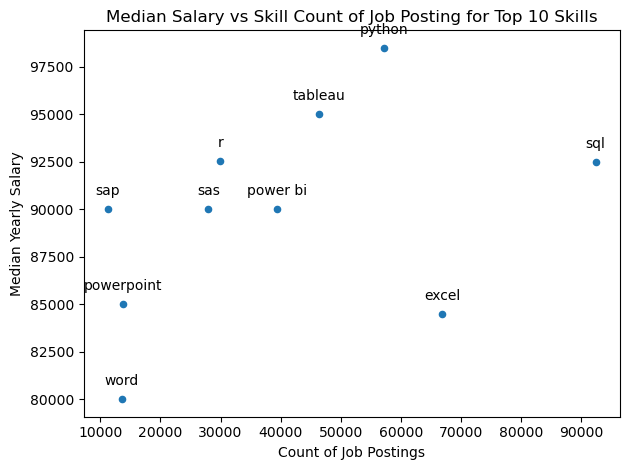

In [20]:
skill_stats.plot(kind='scatter',y='median_salary',x='skill_count')
plt.title('Median Salary vs Skill Count of Job Posting for Top 10 Skills')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.tight_layout()
for i, txt in enumerate(skill_stats.index):
    plt.annotate(txt, (skill_stats['skill_count'][i], skill_stats['median_salary'][i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()